In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
import plotly.express as px
import inspect
import time
import warnings
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)
from sklearn.metrics import mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.ar_model import AutoReg
%matplotlib inline

In [2]:
# Read the CSV file into a DataFrame
df = pd.read_csv(r"D:\HN -Air\Air_Quality-Analysis_HN\data\hanoi-aqi-weather-data.csv")  # Replace 'file.csv' with the path to your CSV file

# Convert 'Local Time' column to datetime object
df['Local Time'] = pd.to_datetime(df['Local Time'])

# Set 'Local Time' column as index
df.set_index('Local Time', inplace=True)

# Display the DataFrame
df  # Use df.head() to display the first few rows of the DataFrame

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\HN -Air\\Air_Quality-Analysis_HN\\data\\hanoi-aqi-weather-data.csv'

In [33]:
df_pm25_hourly = df[['PM25']].copy()
df_pm25_daily = df_pm25_hourly.resample('D')['PM25'].agg('mean') ## Resample dữ liệu theo ngày và tính giá trị trung bình
df_pm25 = df_pm25_daily
df_pm25

Local Time
2023-01-01     71.541667
2023-01-02     90.375000
2023-01-03     65.916667
2023-01-04     97.166667
2023-01-05     72.500000
                 ...    
2024-12-27     49.958333
2024-12-28     44.167083
2024-12-29     78.597083
2024-12-30    100.277917
2024-12-31     86.299500
Freq: D, Name: PM25, Length: 731, dtype: float64

In [4]:
df_pm25.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 731 entries, 2023-01-01 to 2024-12-31
Freq: D
Series name: PM25
Non-Null Count  Dtype  
--------------  -----  
731 non-null    float64
dtypes: float64(1)
memory usage: 11.4 KB


In [5]:
# Perform ADF test
adf_result = adfuller(df_pm25)
print('ADF Statistic:', adf_result[0])
print('p-value:', adf_result[1])
print('Critical Values:', adf_result[4])

ADF Statistic: -6.5148641359401935
p-value: 1.0776256378814557e-08
Critical Values: {'1%': -3.4393644334758475, '5%': -2.8655182850048306, '10%': -2.568888486973192}


+ ADF Statistic (-6.5149) nhỏ hơn tất cả các giá trị Critical Values tại các mức ý nghĩa 1%, 5%, và 10%. Điều này cho thấy chuỗi thời gian là stationary và không có đơn vị gốc.
+ Gía trị p-value < 0.05, kết luận chúng ta sẽ bác bỏ giả thuyết  null (null hypothesis)
. Phương trình đặc trưng không có nghiệm đơn vị. Do đó chuỗi lợi suất có tính chất dừng.

<Axes: title={'center': 'Hanoi PM2.5 Levels, Daily Data'}, xlabel='Date', ylabel='PM2.5 Level'>

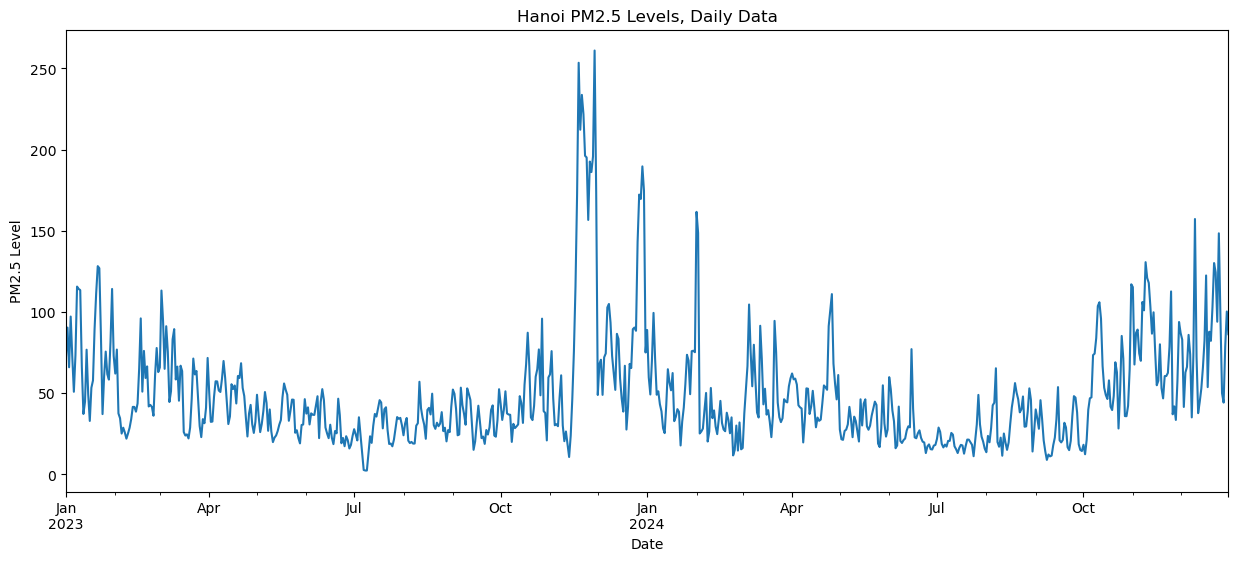

In [34]:
fig, ax = plt.subplots(figsize=(15, 6))
df_pm25.plot(xlabel = "Date",ylabel= "PM2.5 Level",
                           title= "Hanoi PM2.5 Levels, Daily Data", ax=ax)

Text(0.5, 1.0, 'Hanoi PM2.5 Readings, ACF')

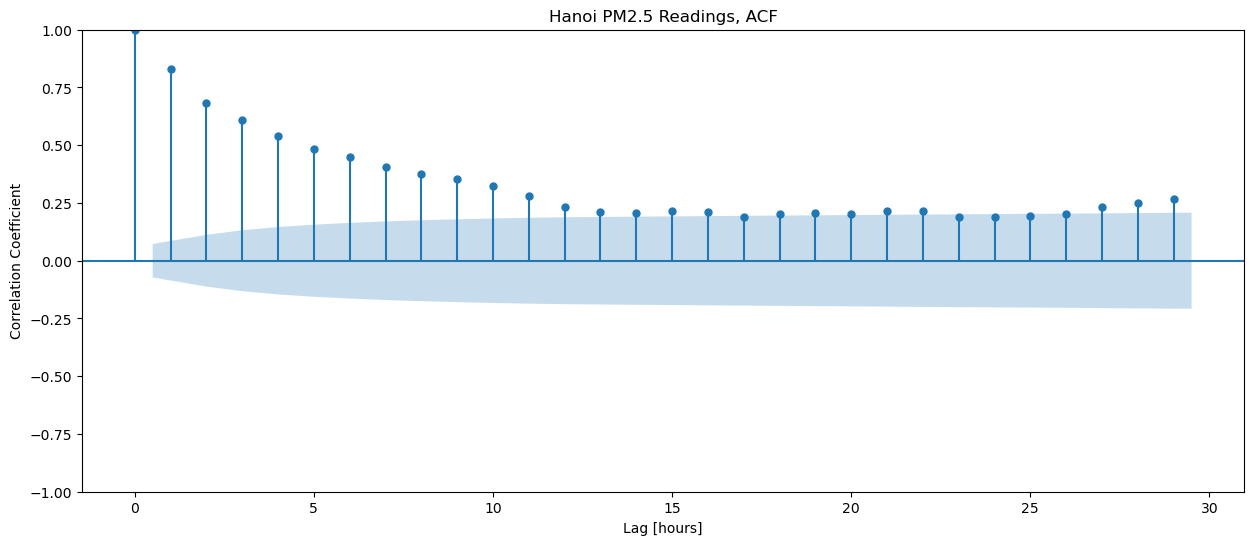

In [7]:
fig, ax = plt.subplots(figsize=(15, 6))
plot_acf(df_pm25, ax=ax)
plt.xlabel("Lag [hours]")
plt.ylabel("Correlation Coefficient")
plt.title("Hanoi PM2.5 Readings, ACF")

 Nếu tại một độ trễ nhỏ nhất mà đoạn thẳng (vuông góc với trục hoành) mà độ dài đại diện cho giá trị của hệ số tự tương quan nằm ngoài khoảng tin cậy thì đó chính là độ trễ phù hợp lớn nhất mà ta nên lựa chọn cho quá trình trung bình trượt. 
 
q là tham số cho phần Moving Average (MA) trong mô hình ARIMA. Để chọnq, bạn cần tìm độ trễ (lag) tại đó hệ số tự tương quan vượt qua vùng tin cậy 95% và sau đó không còn vượt qua các độ trễ lớn hơn.ất.

Text(0.5, 1.0, 'Hanoi PM2.5 Readings, PACF')

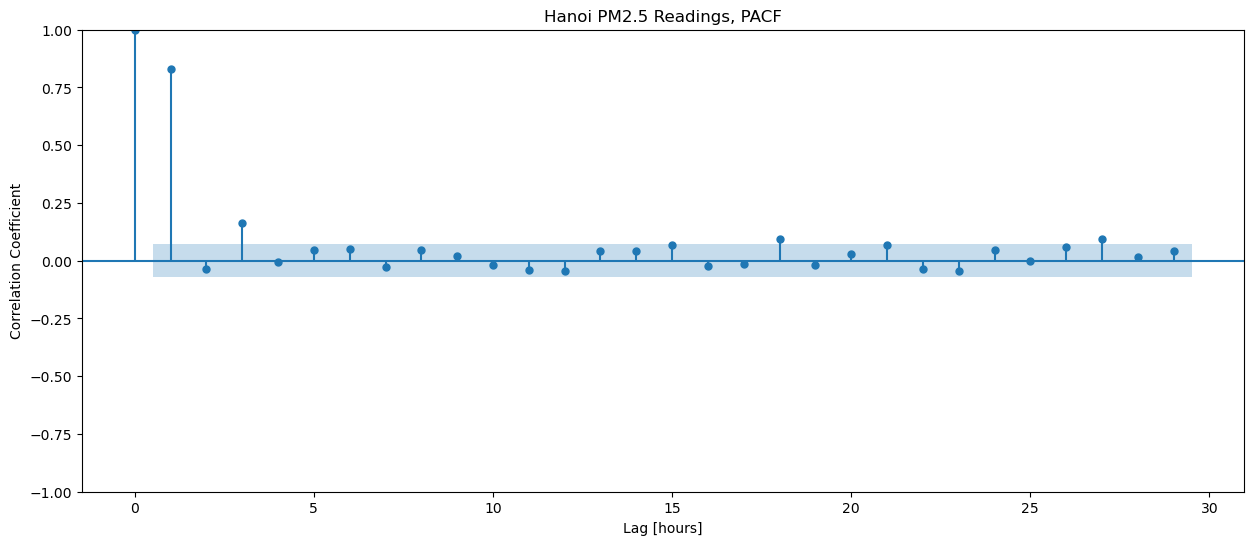

In [8]:
fig, ax = plt.subplots(figsize=(15, 6))
plot_pacf(df_pm25, ax=ax)
plt.xlabel("Lag [hours]")
plt.ylabel("Correlation Coefficient")
plt.title("Hanoi PM2.5 Readings, PACF")

In [ ]:
int(len(df_pm25)) *0.8

584.8000000000001

In [38]:
# Tính chỉ số phân tách cho 80% dữ liệu
cutoff_test = int(len(df_pm25) * 0.8) 

# Chia dữ liệu thành hai phần: training set và test set
df_pm25_train = df_pm25.iloc[:cutoff_test]  # 80% đầu tiên cho training
df_pm25_test = df_pm25.iloc[cutoff_test:]   # 20% còn lại cho testing

# In ra kích thước của cả hai tập
print("df_pm25_train shape:", df_pm25_train.shape)
print("df_pm25_test shape:", df_pm25_test.shape)


df_pm25_train shape: (584,)
df_pm25_test shape: (147,)


+ df_pm25_train sẽ chứa 80% đầu dữ liệu.
+ df_pm25_test sẽ chứa 20% còn lại của dữ liệu.

In [11]:
# Perform ADF test
adf_result = adfuller(df_pm25_train)
print('ADF Statistic:', adf_result[0])
print('p-value:', adf_result[1])
print('Critical Values:', adf_result[4])

ADF Statistic: -5.83051260552405
p-value: 3.9853228609948983e-07
Critical Values: {'1%': -3.4416553818946145, '5%': -2.8665274458710064, '10%': -2.5694261699959413}


In [39]:
# Tính giá trị trung bình của df_pm25_train
df_pm25_train_mean = df_pm25_train.mean()

# Tạo dự đoán baseline (dự đoán giá trị trung bình cho tất cả các điểm)
df_pm25_pred_baseline = [df_pm25_train_mean] * len(df_pm25_train)

# Tính toán Mean Absolute Error (MAE) giữa giá trị thực tế và dự đoán baseline
mae_baseline = mean_absolute_error(df_pm25_train, df_pm25_pred_baseline)

# In ra giá trị trung bình và MAE
print("Mean P2 Reading:", round(df_pm25_train_mean, 2))
print("Baseline MAE:", round(mae_baseline, 2))


Mean P2 Reading: 47.51
Baseline MAE: 22.86


### Kết quả:
+ Mean P2 Reading: Giá trị trung bình của df_pm25_train, tức là trung bình của các giá trị PM2.5 trong tập huấn luyện.
+ Baseline MAE: MAE giữa giá trị thực tế và dự đoán baseline, cho bạn biết mức độ sai lệch của mô hình dựa trên giả định rằng tất cả các giá trị dự đoán đều bằng với giá trị trung bình.
### Mục đích của việc tính MAE Baseline:
+ MAE baseline là một cách đơn giản để đánh giá mô hình dự báo. Nếu phát triển một mô hình phức tạp hơn mà không thể vượt qua MAE baseline, điều đó cho thấy mô hình có thể chưa được tối ưu hóa tốt.


In [13]:
p_params = range(0, 8, 1)
q_params = range(0, 3, 1)
list(p_params)

[0, 1, 2, 3, 4, 5, 6, 7]

In [36]:
# Tạo từ điển để lưu MAE cho các cặp tham số (p, q)
mae_grid = dict()

# Vòng lặp ngoài: Lặp qua các giá trị có thể của tham số `p`
for p in p_params:
    # Tạo cặp khóa-giá trị trong từ điển. Khóa là `p`, giá trị là danh sách rỗng.
    mae_grid[p] = list()

    # Vòng lặp trong: Lặp qua các giá trị có thể của tham số `q`
    for q in q_params:
        # Tạo bộ tham số (p, 0, q) cho mô hình ARIMA (p: số bậc tự hồi quy, d=0, q: số bậc trung bình động)
        order = (p, 0, q)

        # Ghi lại thời gian bắt đầu huấn luyện mô hình
        start_time = time.time()

        # Huấn luyện mô hình ARIMA với tham số `order` đã tạo
        model = ARIMA(df_pm25_train, order=order).fit()

        # Tính toán thời gian huấn luyện mô hình
        elapsed_time = round(time.time() - start_time, 2)
        print(f"Trained ARIMA {order} in {elapsed_time} seconds.")  # In ra thời gian huấn luyện

        # Dự báo giá trị PM2.5 trong mẫu huấn luyện (training) từ mô hình ARIMA đã huấn luyện
        df_pm25_pred = model.predict()

        # Tính toán MAE (Mean Absolute Error) giữa giá trị thực tế và giá trị dự báo
        mae = mean_absolute_error(df_pm25_train, df_pm25_pred)

        # Thêm giá trị MAE vào danh sách trong từ điển tương ứng với giá trị `p`
        mae_grid[p].append(mae)

# In kết quả từ điển `mae_grid` chứa MAE cho các giá trị `p` và `q`
print()
print(mae_grid)

Trained ARIMA (0, 0, 0) in 0.06 seconds.
Trained ARIMA (0, 0, 1) in 0.06 seconds.
Trained ARIMA (0, 0, 2) in 0.14 seconds.
Trained ARIMA (1, 0, 0) in 0.08 seconds.
Trained ARIMA (1, 0, 1) in 0.09 seconds.
Trained ARIMA (1, 0, 2) in 0.13 seconds.
Trained ARIMA (2, 0, 0) in 0.03 seconds.
Trained ARIMA (2, 0, 1) in 0.16 seconds.


D:\java code\TQHDl\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
D:\java code\TQHDl\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Trained ARIMA (2, 0, 2) in 0.25 seconds.
Trained ARIMA (3, 0, 0) in 0.06 seconds.
Trained ARIMA (3, 0, 1) in 0.17 seconds.
Trained ARIMA (3, 0, 2) in 0.62 seconds.
Trained ARIMA (4, 0, 0) in 0.16 seconds.
Trained ARIMA (4, 0, 1) in 0.27 seconds.


D:\java code\TQHDl\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
D:\java code\TQHDl\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Trained ARIMA (4, 0, 2) in 0.68 seconds.
Trained ARIMA (5, 0, 0) in 0.16 seconds.
Trained ARIMA (5, 0, 1) in 0.41 seconds.


D:\java code\TQHDl\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
D:\java code\TQHDl\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Trained ARIMA (5, 0, 2) in 0.71 seconds.
Trained ARIMA (6, 0, 0) in 0.27 seconds.
Trained ARIMA (6, 0, 1) in 0.37 seconds.
Trained ARIMA (6, 0, 2) in 0.79 seconds.
Trained ARIMA (7, 0, 0) in 0.3 seconds.
Trained ARIMA (7, 0, 1) in 0.46 seconds.
Trained ARIMA (7, 0, 2) in 0.87 seconds.

{0: [22.85696439721964, 16.289556771585474, 14.388829775167261], 1: [12.49777277598886, 12.500306408976732, 12.335218851651549], 2: [12.495287388545117, 12.452083276166368, 12.34245979897062], 3: [12.33968130006479, 12.362172932812568, 12.333279468077603], 4: [12.368695287871386, 12.367253681034825, 12.31828592765682], 5: [12.342548688485449, 12.313040795203007, 12.174541063437548], 6: [12.311235011796176, 12.274237888239599, 12.289501135475108], 7: [12.29942651199503, 12.274976513645392, 12.276447106941097]}


In [37]:
mae_df = pd.DataFrame(mae_grid)
mae_df.round(4)

,0,1,2,3,4,5,6,7
0,22.8570,12.4978,12.4953,12.3397,12.3687,12.3425,12.3112,12.2994
1,16.2896,12.5003,12.4521,12.3622,12.3673,12.3130,12.2742,12.2750
2,14.3888,12.3352,12.3425,12.3333,12.3183,12.1745,12.2895,12.2764


+ chọn MAE thấp nhất 
+ MAE thấp hơn nghĩa là mô hình có dự báo chính xác hơn.
+ MAE (Mean Absolute Error) là một chỉ số đánh giá độ chính xác của mô hình dự báo. Nó đo lường sai số tuyệt đối trung bình giữa giá trị thực tế và giá trị dự báo của mô hình. MAE giúp bạn hiểu mô hình của mình dự báo chính xác như thế nào.


( 5 0 2 )


D:\java code\TQHDl\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
D:\java code\TQHDl\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


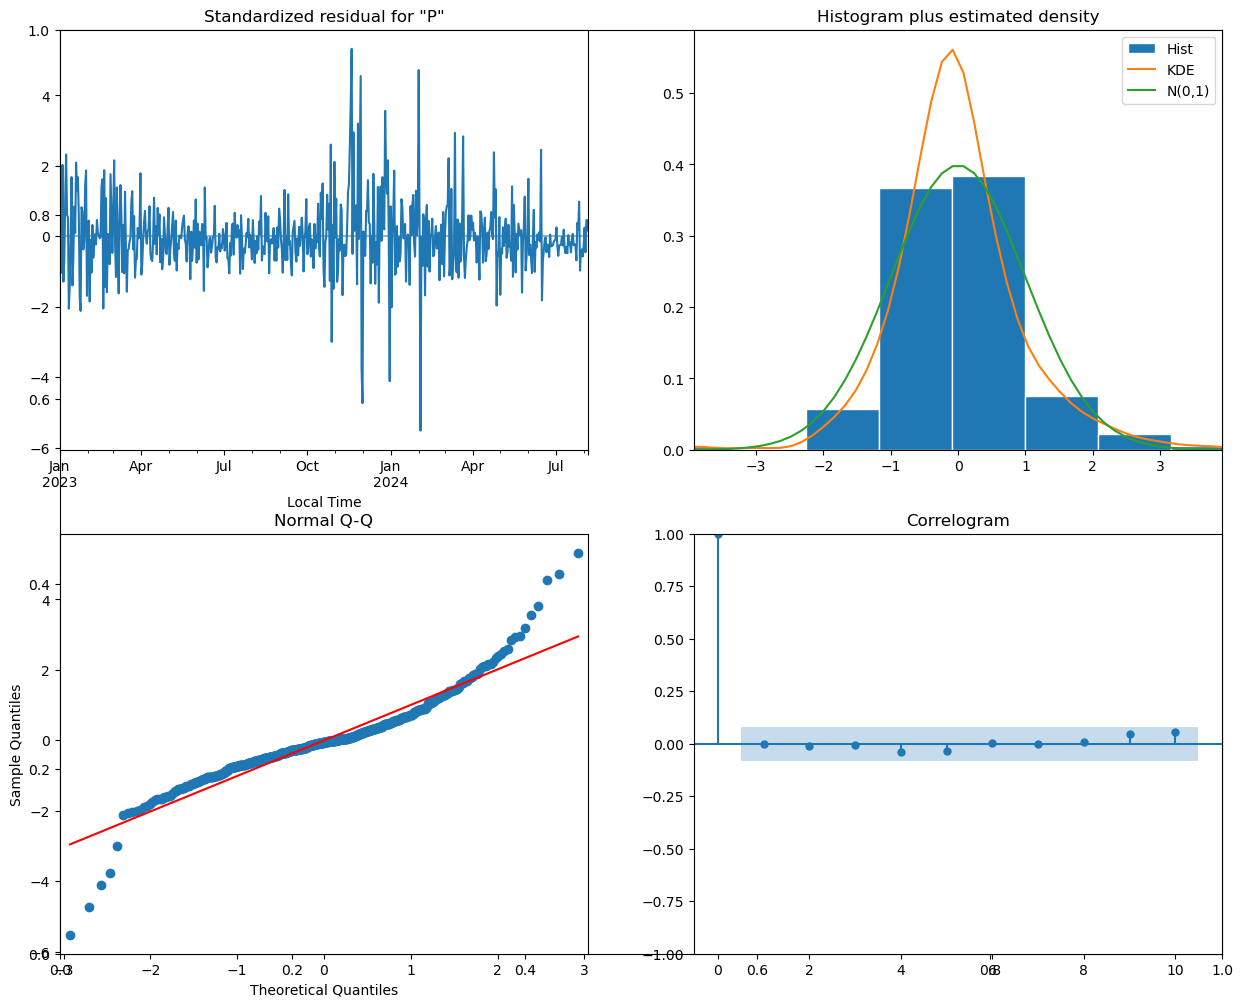

In [41]:
# Tạo và huấn luyện mô hình ARIMA
model = ARIMA(df_pm25_train, order=(5, 0, 2))
results = model.fit()

# Vẽ các biểu đồ chẩn đoán của mô hình
fig, ax = plt.subplots(figsize=(15, 12))
results.plot_diagnostics(fig=fig)

# Lưu biểu đồ vào tệp hình ảnh
plt.savefig('example_plot.png')


1. Standardized Residual for "P"

Ý nghĩa: Biểu đồ này thể hiện phần dư chuẩn hóa của mô hình ARIMA. Phần dư chuẩn hóa là sự khác biệt giữa các giá trị thực tế và giá trị dự đoán, được chuẩn hóa sao cho có trung bình bằng 0 và phương sai bằng 1. Việc chuẩn hóa giúp đánh giá chính xác hơn sự khác biệt giữa giá trị thực và giá trị dự đoán.

Phân tích:

Nếu phần dư không có xu hướng rõ ràng, tức là phân phối quanh giá trị 0 và không có cấu trúc hay chu kỳ theo thời gian, mô hình đã dự đoán tốt và không bỏ sót thông tin quan trọng.

Trong trường hợp này, bạn có thể thấy các phần dư dao động khá ngẫu nhiên quanh giá trị 0, điều này cho thấy mô hình đã bắt kịp cấu trúc chuỗi thời gian mà không bỏ sót bất kỳ yếu tố nào quan trọng.

Kết luận: Mô hình ARIMA đã khớp tốt với dữ liệu và không bị bias (thiên lệch).

2. Histogram plus Estimated Density

Ý nghĩa: Biểu đồ này giúp kiểm tra sự phân phối của phần dư. Cột histogram thể hiện tần suất của các giá trị phần dư, còn estimated density là ước lượng phân phối xác suất của phần dư, và đường N(0,1) là phân phối chuẩn với trung bình 0 và phương sai 1.

Phân tích:

Nếu phân phối của phần dư gần giống với phân phối chuẩn (N(0,1)), điều này có nghĩa là mô hình đã dự đoán đúng và không có sự thiên lệch trong các dự đoán.

Biểu đồ của bạn cho thấy phần dư của mô hình có phân phối gần giống phân phối chuẩn, với một đỉnh rõ ràng ở giá trị gần 0 và sự phân bố đều đặn từ trái sang phải. Điều này là dấu hiệu cho thấy mô hình ARIMA của bạn phù hợp với giả thuyết phân phối chuẩn.

Kết luận: Mô hình ARIMA có thể coi là hợp lý, không có sự thiên lệch rõ ràng trong phần dư.

3. Normal Q-Q

Ý nghĩa: Q-Q plot (Quantile-Quantile plot) là công cụ kiểm tra xem phần dư có phân phối chuẩn hay không. Nếu các điểm trên Q-Q plot nằm gần đường chéo đỏ, nghĩa là phần dư có phân phối chuẩn.

Phân tích:

Trong biểu đồ này, các điểm nằm rất gần với đường chéo đỏ, cho thấy phần dư của mô hình thực sự có phân phối chuẩn. Điều này hỗ trợ giả thuyết rằng mô hình đã dự báo một cách chính xác và các sai số (phần dư) không có bất kỳ sự bất thường nào.

Nếu các điểm phân tán xa khỏi đường đỏ, điều này có thể chỉ ra rằng phần dư không có phân phối chuẩn và mô hình cần phải điều chỉnh.

Kết luận: Phần dư của mô hình có phân phối chuẩn, cho thấy mô hình ARIMA đã dự đoán chính xác.

4. Correlogram

Ý nghĩa: Correlogram là biểu đồ tự tương quan (autocorrelation) của phần dư. Biểu đồ này giúp bạn kiểm tra xem phần dư có tự tương quan hay không, tức là có mối liên hệ giữa các giá trị phần dư ở các thời điểm khác nhau.

Phân tích:

Một mô hình ARIMA tốt sẽ tạo ra phần dư không có tự tương quan, tức là không có sự phụ thuộc mạnh mẽ giữa các giá trị phần dư ở các độ trễ (lag) khác nhau.

Trong biểu đồ của bạn, các giá trị tự tương quan (ACF) đều nằm gần mức 0 và không vượt qua vùng mờ, điều này cho thấy phần dư không có tự tương quan. Điều này có nghĩa là mô hình đã làm tốt trong việc bắt đúng các xu hướng của dữ liệu, và phần dư không có cấu trúc mà mô hình còn lại chưa bắt được.

Kết luận: Không có tự tương quan trong phần dư, điều này chứng tỏ mô hình ARIMA đã mô hình hóa hoàn toàn cấu trúc chuỗi thời gian mà không bỏ sót thông tin.

In [46]:
# Khởi tạo Series rỗng để chứa dự đoán
df_pm25_pred_wfv = pd.Series()  
history = df_pm25_train.copy()

# Dự báo từng bước trong tập kiểm tra
for i in range(len(df_pm25_test)):
    # Huấn luyện mô hình ARIMA trên dữ liệu lịch sử
    model = ARIMA(history, order=(5, 0, 2)).fit()
    
    # Dự báo giá trị tiếp theo
    next_pred = model.forecast()
    
    # Thêm dự đoán vào Series kết quả
    df_pm25_pred_wfv = pd.concat([df_pm25_pred_wfv, pd.Series(next_pred)])
    
    # Làm tròn các giá trị dự đoán xuống 2 chữ số
    df_pm25_pred_wfv = df_pm25_pred_wfv.round(2)
    
    # Cập nhật lịch sử với dữ liệu thực tế từ df_pm25_test
    history = pd.concat([history, df_pm25_test[next_pred.index]])

D:\java code\TQHDl\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
D:\java code\TQHDl\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\media\AppData\Local\Temp\ipykernel_18360\4086481606.py:14: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  df_pm25_pred_wfv = pd.concat([df_pm25_pred_wfv, pd.Series(next_pred)])
D:\java code\TQHDl\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autor

In [43]:
df_pm25_pred_wfv

2024-08-07    43.10
2024-08-08    65.21
2024-08-09    16.06
2024-08-10    30.44
2024-08-11    23.88
              ...  
2024-12-27    76.62
2024-12-28    60.31
2024-12-29    52.57
2024-12-30    68.04
2024-12-31    95.69
Freq: D, Length: 147, dtype: float64

In [44]:
test_mae = mean_absolute_error(df_pm25_test, df_pm25_pred_wfv)
print("Test MAE (walk forward validation):", round(test_mae, 2))

Test MAE (walk forward validation): 15.69


Test MAE (walk forward validation): Giá trị MAE này cho bạn biết mức độ chính xác của mô hình ARIMA khi dự đoán dữ liệu trong tập kiểm tra. Giá trị MAE càng nhỏ thì mô hình càng hiệu quả.

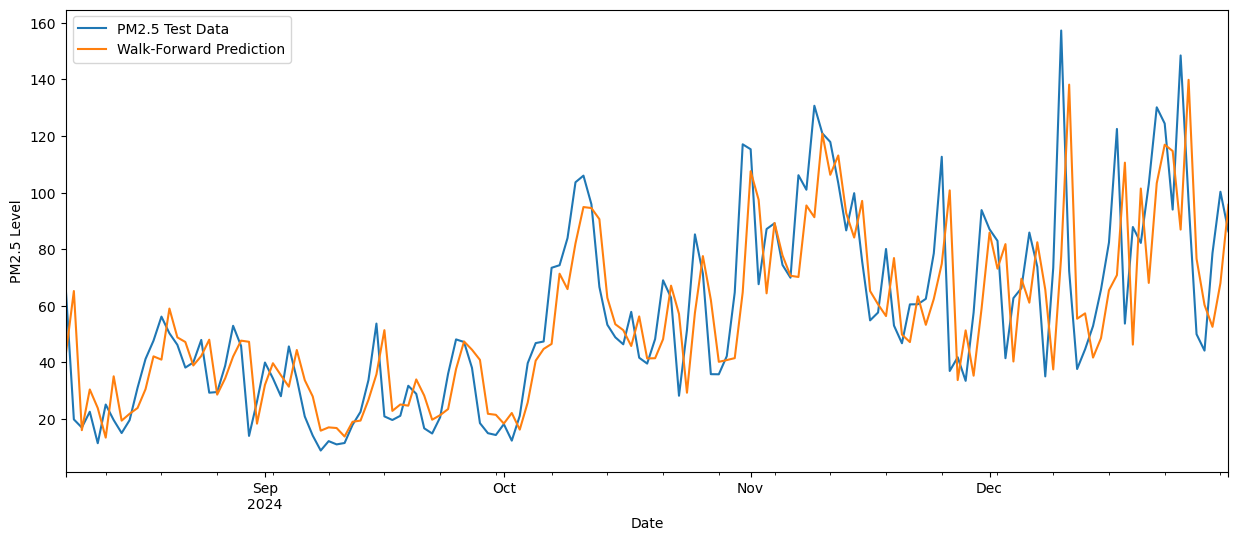

In [45]:
ax = df_pm25_test.plot(label = 'PM2.5 Test Data', figsize=(15, 6))
df_pm25_pred_wfv.plot(ax=ax, label='Walk-Forward Prediction')
plt.ylabel('PM2.5 Level')
plt.xlabel('Date')
plt.legend()
plt.show()

Biểu đồ trên cho thấy sự so sánh giữa dữ liệu thử nghiệm PM2.5 và Dự đoán Tiến tới (Walt-Forward Prediction). Đường màu xanh biểu thị mức PM2.5 thực tế được quan sát trong tập dữ liệu thử nghiệm, trong khi đường màu cam biểu thị các dự đoán được thực hiện bởi mô hình ARIMA bằng cách sử dụng xác thực tiến tới (Walt-Forward Validation).

Từ biểu đồ, có thể thấy rõ rằng các dự đoán của mô hình bám sát xu hướng dữ liệu thử nghiệm thực tế, nắm bắt được các đỉnh và đáy đáng kể. Điều này cho thấy mô hình hoạt động tốt trong việc dự báo mức PM2.5, mang lại dự đoán mạnh mẽ và đáng tin cậy. Sự gần gũi của hai đường cho thấy mô hình hiệu quả trong việc nắm bắt các mô hình cơ bản và tính thời vụ hiện diện trong dữ liệu chuỗi thời gian

### Biểu đồ so sánh giữa dữ liệu PM2.5 thực tế (dùng màu xanh dương) và dự đoán từ phương pháp walk-forward validation (dùng màu cam). Cả hai đường đều thể hiện mức độ ô nhiễm PM2.5 theo thời gian, với các đỉnh và đáy phản ánh sự thay đổi của chỉ số PM2.5 qua các tháng.
### Kết luận:
+ Mức độ tương đồng: Đường màu cam (dự đoán từ ARIMA) khá gần với đường màu xanh dương (dữ liệu thực tế), điều này cho thấy mô hình ARIMA hoạt động khá tốt trong việc dự đoán mức độ ô nhiễm PM2.5.
+ Sai lệch: Một số giai đoạn, mô hình ARIMA có thể dự đoán không chính xác, nhất là vào các đỉnh hoặc đáy dữ liệu. Tuy nhiên, tổng thể, mô hình vẫn dự đoán khá chính xác.
+ Đánh giá mô hình: Nếu sai lệch này là chấp nhận được, thì mô hình ARIMA có thể được coi là một công cụ hữu ích trong việc dự báo chỉ số PM2.5 trong tương lai. Bạn có thể cải thiện mô hình bằng cách thử các tham số khác cho ARIMA hoặc thêm các yếu tố mùa vụ và xu hướng vào mô hình.